## Importing libraries

In [1]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
from lib import Dense, Tanh, Sigmoid, MSE, SGD, Network, ReLU, Dropout
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf



## 1. Gradient checking

### Initialize inputs, outputs and layers

In [2]:
np.random.seed(43) #to get the same random data every time for reproducability
x = np.array([[0.1,0.98]])
y = np.array ([[1]])
test_layer = Dense(2,1)
test_loss = MSE()


### Analytical gradient

In [3]:
out = test_layer.forward(x)
loss = test_loss.forward(out,y)
gradient_lib = test_loss.backward()
test_layer.backward(gradient_lib)

array([[-0.95988129,  3.38785774]])

Isolating one of the gradients

In [4]:
analytical_grad = test_layer.dW[0, 0]  
print(analytical_grad)

-0.3729143623181157


### Calculating numerical gradient

In [5]:
epsilon = 1e-5
original_w = test_layer.W[0, 0]

# Forward pass with W + epsilon
test_layer.W[0, 0] = original_w + epsilon
out_plus = test_layer.forward(x)
loss_plus = test_loss.forward(out_plus, y)

# Forward pass with W - epsilon
test_layer.W[0, 0] = original_w - epsilon
out_minus = test_layer.forward(x)
loss_minus = test_loss.forward(out_minus, y)

Analyzing the difference between them

In [6]:
test_layer.W[0, 0] = original_w

numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)

print(f"Analytical Gradient (Backprop): {analytical_grad:.8f}")
print(f"Numerical Gradient (Formula):   {numerical_grad:.8f}")
print(f"Difference:                     {abs(analytical_grad - numerical_grad):.8e}\n")


Analytical Gradient (Backprop): -0.37291436
Numerical Gradient (Formula):   -0.37291436
Difference:                     4.95221086e-11



---
## 2. The XOR problem

### Initialising inputs, outputs and layers

In [7]:
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

hidden_layer_1 = Dense(2,4)
activation1 = Tanh()
hidden_layer_2 = Dense(4,1)
activation2 = Sigmoid()

### Buidling the network

In [8]:
Layers = [hidden_layer_1,activation1,hidden_layer_2,activation2]
NN = Network(Layers, MSE(), SGD(learning_rate=0.1, momentum=0.9))

### Training

In [9]:
Epochs = 1000
error = np.zeros(shape=(Epochs,1))
for Epoch in range(Epochs):
    error[Epoch] = NN.train_step(x,y)


### Testing


--- Final Results ---
Input: [0 0] | True: 0 | Predicted: 0.0201
Input: [0 1] | True: 1 | Predicted: 0.9617
Input: [1 0] | True: 1 | Predicted: 0.9685
Input: [1 1] | True: 0 | Predicted: 0.0410


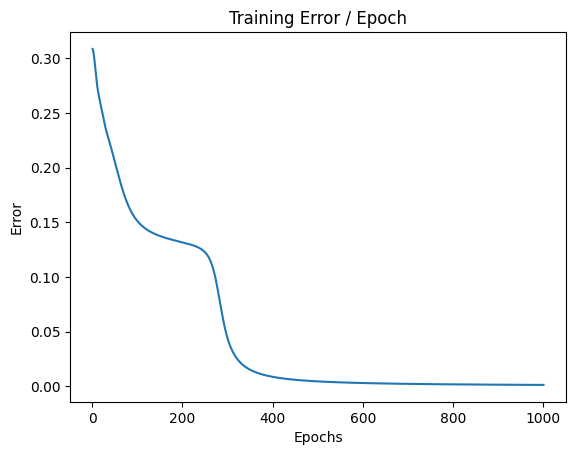

In [10]:
print("\n--- Final Results ---")
CLib_predictions = NN.forward(x)

for i in range(len(x)):
    print(f"Input: {x[i]} | True: {y[i][0]} | Predicted: {CLib_predictions[i][0]:.4f}")

plt.plot(np.arange(1,Epochs+1),error)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Training Error / Epoch")
plt.show()

---
## 3. Autoencoder
### Load dataset

In [11]:
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### Preprocessing

In [12]:
x_train_clean = x_train_raw.reshape(-1, 784).astype('float32') / 255.0
x_test_clean = x_test_raw.reshape(-1, 784).astype('float32') / 255.0

### noise addition

In [13]:
noise_factor = 0.2

x_train_noisy = x_train_clean + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_clean.shape)
x_test_noisy = x_test_clean + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_clean.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print(f"Training data shape: {x_train_noisy.shape}")
print(f"Testing data shape: {x_test_noisy.shape}")

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


### Dataset Visualization

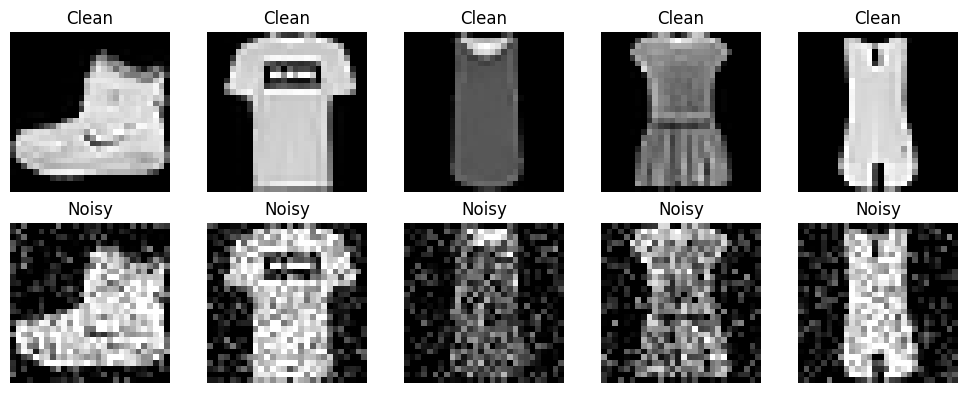

In [14]:
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Display Clean Images (Top Row)
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train_clean[i].reshape(28, 28), cmap='gray')
    ax.set_title("Clean")
    ax.axis('off')

    # Display Noisy Images (Bottom Row)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    ax.set_title("Noisy")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Encoder decoder network layout

In [15]:
# ENCODER
encoder_layers = [
    Dense(784, 128),
    ReLU(),
    Dropout(rate=0.2), # Adding dropout to prevent overfitting on the noise
    Dense(128, 64),
    ReLU(),
    Dense(64, 32)      # Latent Space of 32 dimensions!
]

# DECODER
decoder_layers = [
    Dense(32, 64),
    ReLU(),
    Dense(64, 128),
    ReLU(),
    Dense(128, 784),
    Sigmoid()          # Output pixels are between 0 and 1
]
autoencoder_layers = encoder_layers + decoder_layers
loss_fn = MSE()
optimizer = SGD(learning_rate=0.05, momentum=0.9) 
autoencoder = Network(autoencoder_layers, loss_fn, optimizer)

### Training

In [16]:
epochs = 50
batch_size = 128
num_samples = x_train_noisy.shape[0]

CLib_loss_history = []

for epoch in range(epochs):
    # Shuffle the data at the start of each epoch
    indices = np.random.permutation(num_samples)
    x_train_noisy_shuffled = x_train_noisy[indices]
    x_train_clean_shuffled = x_train_clean[indices]
    
    epoch_loss = 0
    
    # Loop over batches
    for i in range(0, num_samples, batch_size):
        # Extract the batch
        x_batch_noisy = x_train_noisy_shuffled[i : i + batch_size]
        x_batch_clean = x_train_clean_shuffled[i : i + batch_size]
        
        # Train Step: Note that Input is NOISY, but Target is CLEAN!
        batch_loss = autoencoder.train_step(x_batch_noisy, x_batch_clean)
        epoch_loss += batch_loss
        
    # Average loss for the epoch
    epoch_loss /= (num_samples / batch_size)
    CLib_loss_history .append(epoch_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {epoch_loss:.4f}")


Epoch 1/50 | Loss: 0.1381
Epoch 2/50 | Loss: 0.0818
Epoch 3/50 | Loss: 0.0700
Epoch 4/50 | Loss: 0.0610
Epoch 5/50 | Loss: 0.0561
Epoch 6/50 | Loss: 0.0520
Epoch 7/50 | Loss: 0.0487
Epoch 8/50 | Loss: 0.0464
Epoch 9/50 | Loss: 0.0446
Epoch 10/50 | Loss: 0.0434
Epoch 11/50 | Loss: 0.0423
Epoch 12/50 | Loss: 0.0414
Epoch 13/50 | Loss: 0.0405
Epoch 14/50 | Loss: 0.0396
Epoch 15/50 | Loss: 0.0387
Epoch 16/50 | Loss: 0.0380
Epoch 17/50 | Loss: 0.0373
Epoch 18/50 | Loss: 0.0366
Epoch 19/50 | Loss: 0.0360
Epoch 20/50 | Loss: 0.0355
Epoch 21/50 | Loss: 0.0349
Epoch 22/50 | Loss: 0.0345
Epoch 23/50 | Loss: 0.0340
Epoch 24/50 | Loss: 0.0336
Epoch 25/50 | Loss: 0.0332
Epoch 26/50 | Loss: 0.0328
Epoch 27/50 | Loss: 0.0324
Epoch 28/50 | Loss: 0.0321
Epoch 29/50 | Loss: 0.0317
Epoch 30/50 | Loss: 0.0314
Epoch 31/50 | Loss: 0.0311
Epoch 32/50 | Loss: 0.0308
Epoch 33/50 | Loss: 0.0305
Epoch 34/50 | Loss: 0.0303
Epoch 35/50 | Loss: 0.0300
Epoch 36/50 | Loss: 0.0298
Epoch 37/50 | Loss: 0.0296
Epoch 38/5

### Visualization

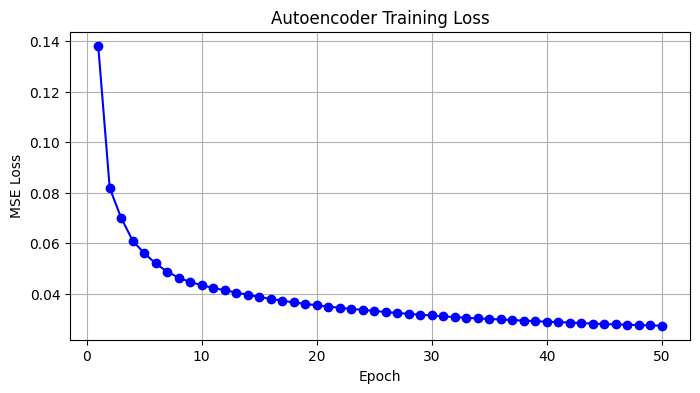


Evaluating on Test Set...


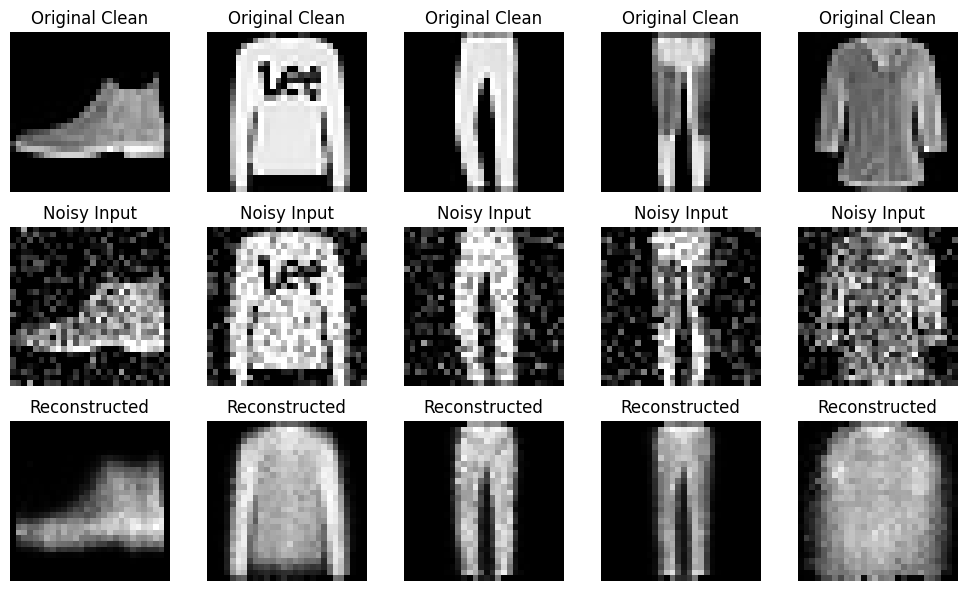

In [17]:
# 3. Plot the Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), CLib_loss_history , marker='o', color='b')
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# 4. Visualization: Original vs Reconstructed 
print("\nEvaluating on Test Set...")
for layer in autoencoder.layers:
    if hasattr(layer, 'is_training'):
        layer.is_training = False

reconstructed_images = autoencoder.forward(x_test_noisy[:5])

plt.figure(figsize=(10, 6))
for i in range(5):
    # Display Original Clean
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(x_test_clean[i].reshape(28, 28), cmap='gray')
    ax.set_title("Original Clean")
    ax.axis('off')

    # Display Noisy Input
    ax = plt.subplot(3, 5, i + 1 + 5)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.set_title("Noisy Input")
    ax.axis('off')
    
    # Display Reconstructed Output
    ax = plt.subplot(3, 5, i + 1 + 10)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
    ax.set_title("Reconstructed")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. SVM

### preparing missing libraries

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA


### Turning off training for layers

In [19]:
for layer in encoder_layers:
    if hasattr(layer, 'is_training'):
        layer.is_training = False

### Feature extraction

In [20]:

def extract_features(data, layers):
    """Passes data through just the encoder half of the network."""
    result = data
    for layer in layers:
        result = layer.forward(result)
    return result
print("Extracting features using the trained encoder...")

x_train_latent = extract_features(x_train_clean, encoder_layers)
x_test_latent = extract_features(x_test_clean, encoder_layers)

print(f"Original shape: {x_train_clean.shape}")
print(f"Latent shape:   {x_train_latent.shape}  <-- Compressed!")


Extracting features using the trained encoder...
Original shape: (60000, 784)
Latent shape:   (60000, 32)  <-- Compressed!


### Visualization


Performing PCA to visualize the 32D latent space in 2D...


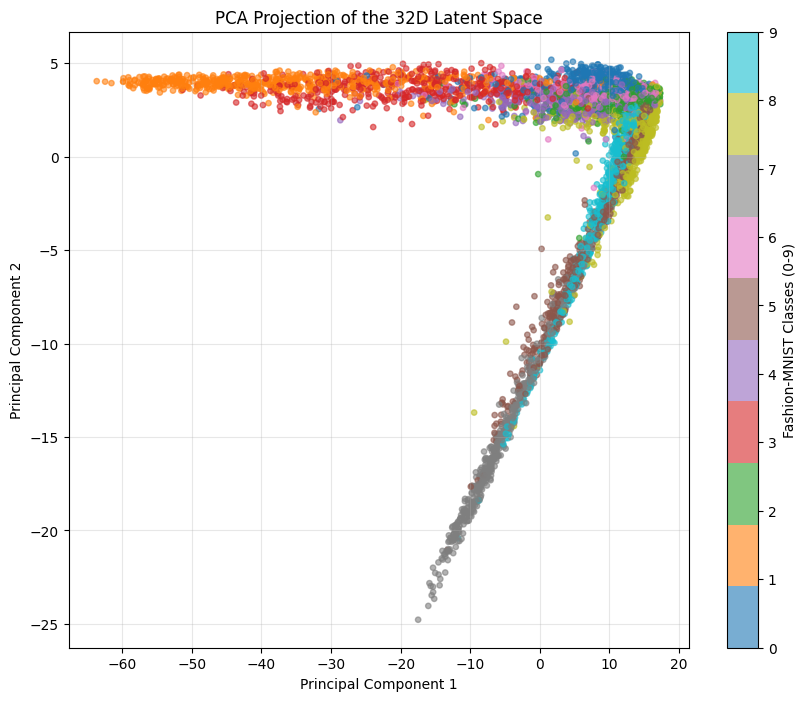


Training SVM on 10000 latent space samples...
Evaluating SVM on the Test Set (10,000 samples)...

SVM Test Accuracy: 72.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.73      1000
           1       0.98      0.89      0.93      1000
           2       0.49      0.64      0.56      1000
           3       0.71      0.79      0.75      1000
           4       0.52      0.53      0.53      1000
           5       0.83      0.81      0.82      1000
           6       0.39      0.24      0.30      1000
           7       0.82      0.82      0.82      1000
           8       0.92      0.90      0.91      1000
           9       0.86      0.88      0.87      1000

    accuracy                           0.73     10000
   macro avg       0.72      0.73      0.72     10000
weighted avg       0.72      0.73      0.72     10000



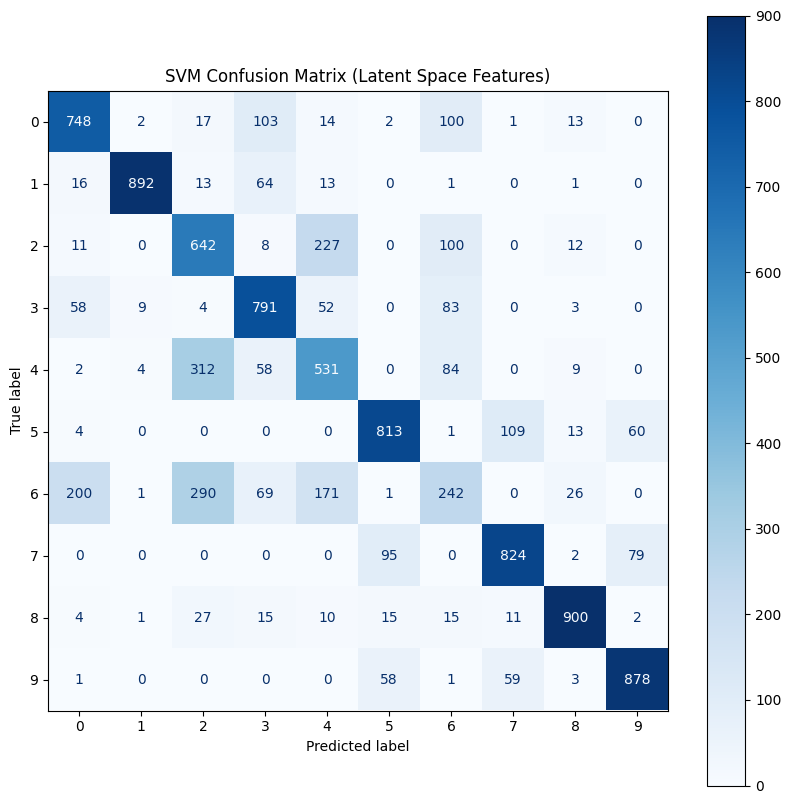

In [21]:
print("\nPerforming PCA to visualize the 32D latent space in 2D...")
pca = PCA(n_components=2)

subset_size = 5000
x_pca = pca.fit_transform(x_train_latent[:subset_size])
y_subset = y_train[:subset_size]

plt.figure(figsize=(10, 8))
# The 'cmap=tab10' gives a distinct color to all 10 clothing classes
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_subset, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Fashion-MNIST Classes (0-9)')
plt.title("PCA Projection of the 32D Latent Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

# 3. SVM Training
svm_train_size = 10000
print(f"\nTraining SVM on {svm_train_size} latent space samples...")

svm_classifier = SVC(kernel='rbf', C=1.0)
svm_classifier.fit(x_train_latent[:svm_train_size], y_train[:svm_train_size])

# 4. Evaluation
print("Evaluating SVM on the Test Set (10,000 samples)...")
y_pred = svm_classifier.predict(x_test_latent)

# Report Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSVM Test Accuracy: {accuracy * 100:.2f}%\n")

# Report Classification Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Report and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("SVM Confusion Matrix (Latent Space Features)")
plt.show()

## 5. Comparison with TensorFlow

### Keras XOR

## Implementation:

In [22]:
import time
#Same x and y arrays from section 2
keras_xor = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='tanh'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
optimizer_xor = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
keras_xor.compile(optimizer=optimizer_xor, loss='mse')

# Time the training
start_time = time.time()
history_xor = keras_xor.fit(x, y, epochs=1000, verbose=0) 
xor_time = time.time() - start_time


### Visualisation & Camparison:

In [23]:
print(f"Keras XOR Training Time: {xor_time:.4f} seconds")
print(f"Keras XOR Final Loss:    {history_xor.history['loss'][-1]:.4f}")
print("Keras XOR Predictions:")
print(keras_xor.predict(x, verbose=0))
print("Our XOR Custom Prediction:")
print(CLib_predictions)
print("Error = ", CLib_predictions-keras_xor.predict(x, verbose=0))

Keras XOR Training Time: 50.4607 seconds
Keras XOR Final Loss:    0.0009
Keras XOR Predictions:
[[0.01264178]
 [0.96877205]
 [0.9693519 ]
 [0.03695824]]
Our XOR Custom Prediction:
[[0.02009516]
 [0.96172484]
 [0.96849402]
 [0.04098974]]
Error =  [[ 0.00745338]
 [-0.00704721]
 [-0.00085787]
 [ 0.00403149]]


### Auto Encoder

In [ ]:
keras_autoencoder = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    # Encoder
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32), 
    # Decoder
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

optimizer_ae = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
keras_autoencoder.compile(optimizer=optimizer_ae, loss='mse')

# Time the training
start_time = time.time()
history_ae = keras_autoencoder.fit(
    x_train_noisy,     # Input
    x_train_clean,     # Target
    batch_size=128,    # Same batch size
    epochs=50,         # Same epochs
    verbose=1          # verbose=1 shows the nice progress bar
)
ae_time = time.time() - start_time

print(f"\nKeras Autoencoder Training Time: {ae_time:.4f} seconds")
print(f"Keras Autoencoder Final Loss:    {history_ae.history['loss'][-1]:.4f}")
print(f"Our Custom library Final Loss: {CLib_loss_history[-1]:.4f} ")

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1184
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0818
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0617
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0539
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0471
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0440
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0425
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0415
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0407
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0399
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0390
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0379
Epoch 13/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0365
Epoch 14/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0351
Epoch 15/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - lo

### Reconstruction visualization

In [ ]:
keras_reconstructed = keras_autoencoder.predict(x_test_noisy[:5])

plt.figure(figsize=(15, 10))
for i in range(5):
    # Display Original Clean
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(x_test_clean[i].reshape(28, 28), cmap='gray')
    ax.set_title("Original")
    ax.axis('off')

    # Display Noisy Input
    ax = plt.subplot(4, 5, i + 1 + 5)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.set_title("Noisy")
    ax.axis('off')
    
    # Display Reconstructed Output
    ax = plt.subplot(4, 5, i + 1 + 10)
    plt.imshow(keras_reconstructed[i].reshape(28, 28), cmap='gray')
    ax.set_title("Keras Reconstruction")
    ax.axis('off')

    ax = plt.subplot(4, 5, i + 1 + 15)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
    ax.set_title("Our Reconstruction")
    ax.axis('off')

plt.tight_layout()
plt.show()